In [9]:
EXP_NAME = "0615_full_pipeline"
TRAINING_DATASET = "heart_disease_train.csv"
TEST_DATASET = "heart_disease_test.csv"
FEATURE_MAP = "scm/uci_scm_config.json"
SEED = 4

In [10]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import userdata
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = userdata.get('PROJECT_ROOT')
else:
  PROJECT_ROOT = '../..'
  if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [11]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel
from notebooks.analysis_utils import mutual_info_grouped, plot_cat_feature, plot_cont_feature, plot_cf_cont_feature_comparison, plot_cf_cat_feature_comparison

from src.config import Config

sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1)

In [12]:
test_latents = pd.read_csv(f'{PROJECT_ROOT}/{Config.DATA_DIR}/{EXP_NAME}/test_latent_space.csv')
test_counterfactuals = pd.read_csv(f'{PROJECT_ROOT}/{Config.DATA_DIR}/{EXP_NAME}/test_counterfactuals.csv')
training_latents = pd.read_csv(f'{PROJECT_ROOT}/{Config.DATA_DIR}/{EXP_NAME}/train_latent_space.csv')
training_counterfactuals = pd.read_csv(f'{PROJECT_ROOT}/{Config.DATA_DIR}/{EXP_NAME}/train_counterfactuals.csv')
test_dataset = pd.read_csv(f'{PROJECT_ROOT}/{Config.DATA_DIR}/{TEST_DATASET}')
training_dataset = pd.read_csv(f'{PROJECT_ROOT}/{Config.DATA_DIR}/{TRAINING_DATASET}')

classifiers_results = pd.read_csv(f'{PROJECT_ROOT}/{Config.RESULTS_DIR}/{EXP_NAME}/bootstrapped_evaluation_results.csv')

with open(f"{PROJECT_ROOT}/configs/{FEATURE_MAP}", 'r') as f:
  feature_map = json.load(f)

In [13]:
training_df = training_latents.merge(training_dataset, how="inner", left_on="patient_index", right_index=True)
training_df = training_df.merge(training_counterfactuals, how="inner", on="patient_index", suffixes=("", "_cf"))
training_df.drop('sample_index_cf', axis=1, inplace=True)

test_df = test_latents.merge(test_dataset, how="inner", left_on="patient_index", right_index=True)
test_df = test_df.merge(test_counterfactuals, how="inner", on="patient_index", suffixes=("", "_cf"))
test_df.drop('sample_index_cf', axis=1, inplace=True)

In [ ]:
desc_cols = [f['name'] for f in feature_map['desc']]
desc_cf_cols = [f"{f['name']}_cf" for f in feature_map['desc']]
latent_cols = [col for col in training_latents.columns if 'u_desc_' in col]
sens_col = feature_map['sens'][0]['name']
target_col = feature_map['target']['name']

In [26]:
from scipy.stats import sem, t
def get_95_ci(data):
  '''
    Calculates the 95% confidence interval for a given set of data.

    Inputs
      data: data as a Pandas Series

    Outputs
      interval: Array of the lower and upper bounds of the confidence interval
  '''
  n = len(data)
  mean = data.mean()
  std_err = sem(data, nan_policy='omit')
  if std_err == 0:
    return (mean, mean)
  interval = t.interval(0.95, n - 1, loc=mean, scale=std_err)
  return interval

def format_avg(metric, precision=3, perc=False):
  ci = get_95_ci(metric)
  if perc:
    return f"{round(metric.mean()*100, precision)}% ({round(ci[0]*100, precision)}%-{round(ci[1]*100, precision)}%)"
  else:
    return f"{round(metric.mean(), precision)} ({round(ci[0], precision)}-{round(ci[1], precision)})"

# Classifier results

In [37]:
from tabulate import tabulate

aggregated_results = classifiers_results.groupby(['model', 'subgroup']).agg({
  "auprc":( lambda x: format_avg(x, precision=2, perc=True)),
  "brier_score":format_avg,
  "recall":( lambda x: format_avg(x, precision=2, perc=True)),
  "ppv":( lambda x: format_avg(x, precision=2, perc=True)),
  "fnr":( lambda x: format_avg(x, precision=2, perc=True)),
  "fpr":( lambda x: format_avg(x, precision=2, perc=True)),
  "cf_harm_balanced":format_avg,
  "cf_harm_pos":format_avg,
  "cf_harm_neg":format_avg,
})

print(aggregated_results.reset_index().to_markdown(index=False))

| model        | subgroup   | auprc                  | brier_score         | recall                 | ppv                   | fnr                 | fpr                    | cf_harm_balanced   | cf_harm_pos   | cf_harm_neg   |
|:-------------|:-----------|:-----------------------|:--------------------|:-----------------------|:----------------------|:--------------------|:-----------------------|:-------------------|:--------------|:--------------|
| fair_unaware | 0.0        | 81.23% (80.44%-82.03%) | 0.14 (0.139-0.142)  | 100.0% (100.0%-100.0%) | 39.92% (39.25%-40.6%) | 0.0% (0.0%-0.0%)    | 42.84% (42.25%-43.42%) | 0.0 (0.0-0.0)      | 0.0 (0.0-0.0) | 0.0 (0.0-0.0) |
| fair_unaware | 1.0        | 94.16% (94.0%-94.33%)  | 0.116 (0.115-0.117) | 91.92% (91.71%-92.13%) | 87.95% (87.7%-88.2%)  | 8.08% (7.87%-8.29%) | 15.9% (15.57%-16.23%)  | 0.0 (0.0-0.0)      | 0.0 (0.0-0.0) | 0.0 (0.0-0.0) |
| fair_unaware | Global     | 90.07% (89.89%-90.26%) | 0.122 (0.121-0.122) | 92.82% (92.63%-93.0

# Latent space

## Mutual Information with $X_{sens}$

### Training dataset


--- Mutual Information with S ---

|          |   count |       mean |        std |        min |        25% |        50% |        75% |       max |
|:---------|--------:|-----------:|-----------:|-----------:|-----------:|-----------:|-----------:|----------:|
| age      |     100 | 0.140484   | 0.0396422  | 0.0266603  | 0.114125   | 0.142222   | 0.166183   | 0.228498  |
| mhr      |     100 | 0.0629312  | 0.0294907  | 0.00412424 | 0.0417884  | 0.0599166  | 0.0826381  | 0.129152  |
| cp       |     100 | 0.0223514  | 0.0179579  | 0          | 0.00707355 | 0.0219954  | 0.034041   | 0.0672109 |
| st       |     100 | 0.0172249  | 0.0186123  | 0          | 0          | 0.0104702  | 0.0306291  | 0.0744578 |
| ang      |     100 | 0.0152116  | 0.0174884  | 0          | 0          | 0.0100801  | 0.022842   | 0.077835  |
| slope    |     100 | 0.0144362  | 0.0165541  | 0          | 0          | 0.0098901  | 0.0220643  | 0.0672913 |
| ecg      |     100 | 0.0118433  | 0.0177698  | 0          

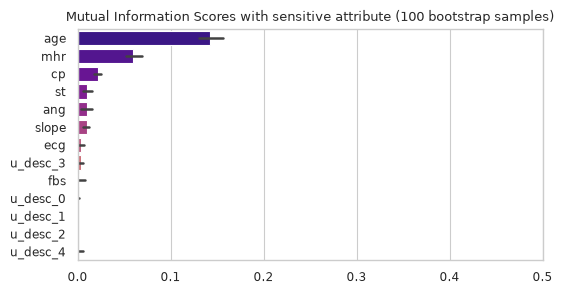

In [38]:
mutual_info_grouped(
  training_df,
  feature_cols= desc_cols + latent_cols,
  target_col=sens_col,
  target_label="sensitive attribute",
  iterations=100,
  n_samples=400,
  seed=SEED
)

### Test dataset


--- Mutual Information with S ---

|          |   count |       mean |        std |   min |       25% |         50% |       75% |       max |
|:---------|--------:|-----------:|-----------:|------:|----------:|------------:|----------:|----------:|
| ang      |     100 | 0.0728765  | 0.0432986  |     0 | 0.0434433 | 0.067833    | 0.0967502 | 0.212718  |
| fbs      |     100 | 0.0449658  | 0.0354298  |     0 | 0.0180701 | 0.0402618   | 0.0682888 | 0.163434  |
| ecg      |     100 | 0.021568   | 0.0268008  |     0 | 0         | 0.012539    | 0.0350386 | 0.107964  |
| cp       |     100 | 0.0206792  | 0.0264866  |     0 | 0         | 0.0100975   | 0.0307684 | 0.108293  |
| u_desc_1 |     100 | 0.0181305  | 0.0256757  |     0 | 0         | 0.00557786  | 0.03019   | 0.101914  |
| u_desc_3 |     100 | 0.0124153  | 0.0180099  |     0 | 0         | 0.00203373  | 0.0194841 | 0.0815642 |
| u_desc_0 |     100 | 0.0165846  | 0.025803   |     0 | 0         | 0.0016558   | 0.0272461 | 0.150021  |
|

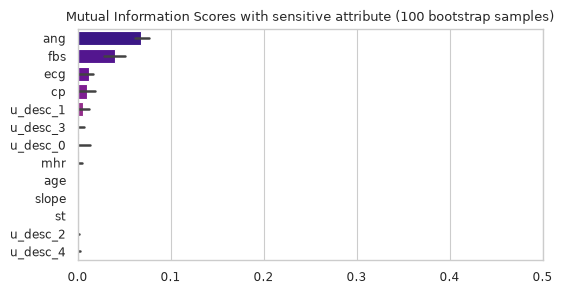

In [39]:
mutual_info_grouped(
  test_df,
  feature_cols= desc_cols + latent_cols,
  target_col=sens_col,
  target_label="sensitive attribute",
  iterations=100,
  n_samples=100,
  seed=SEED
)

# Counterfactuals

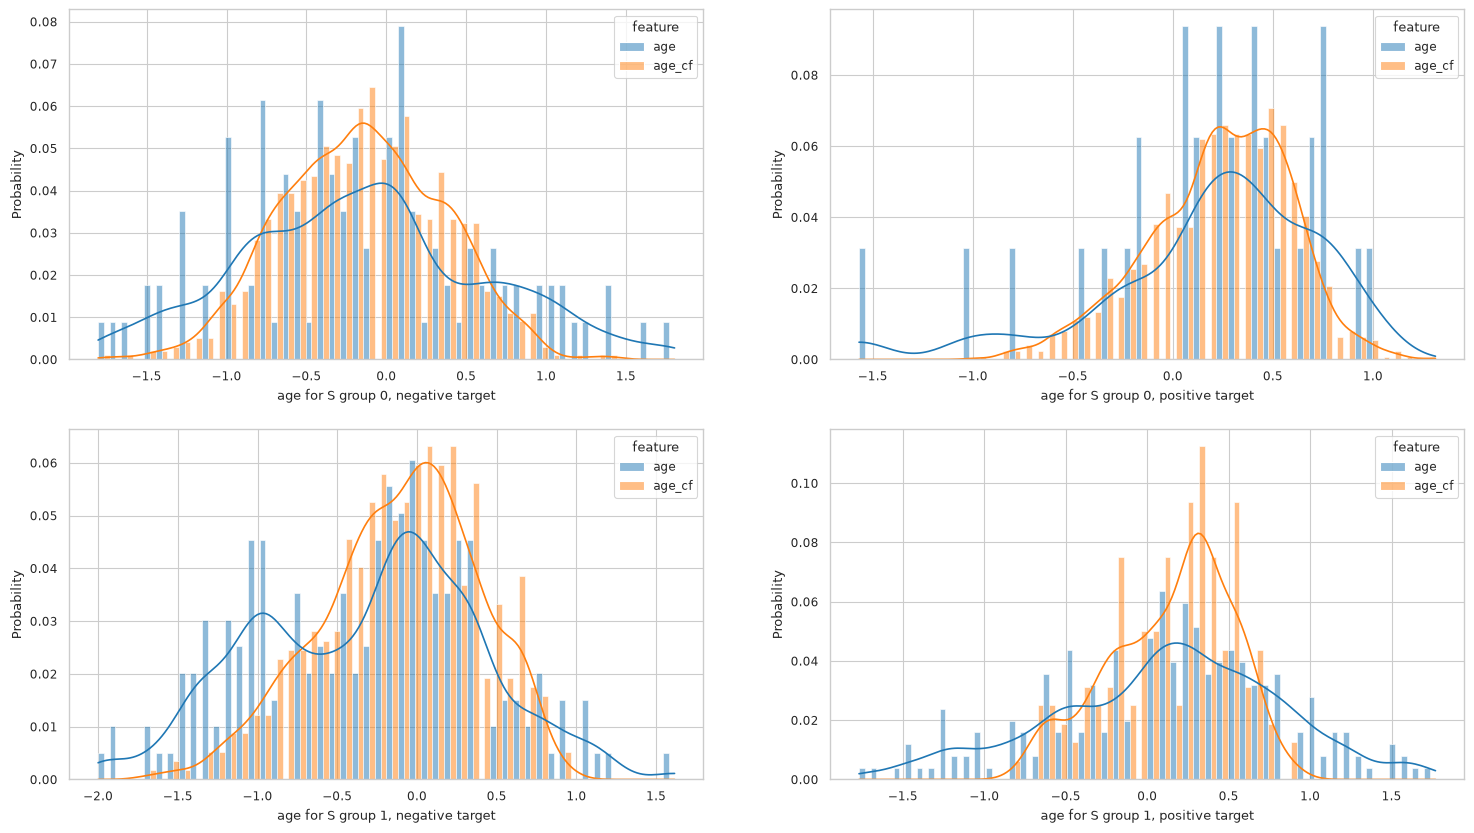

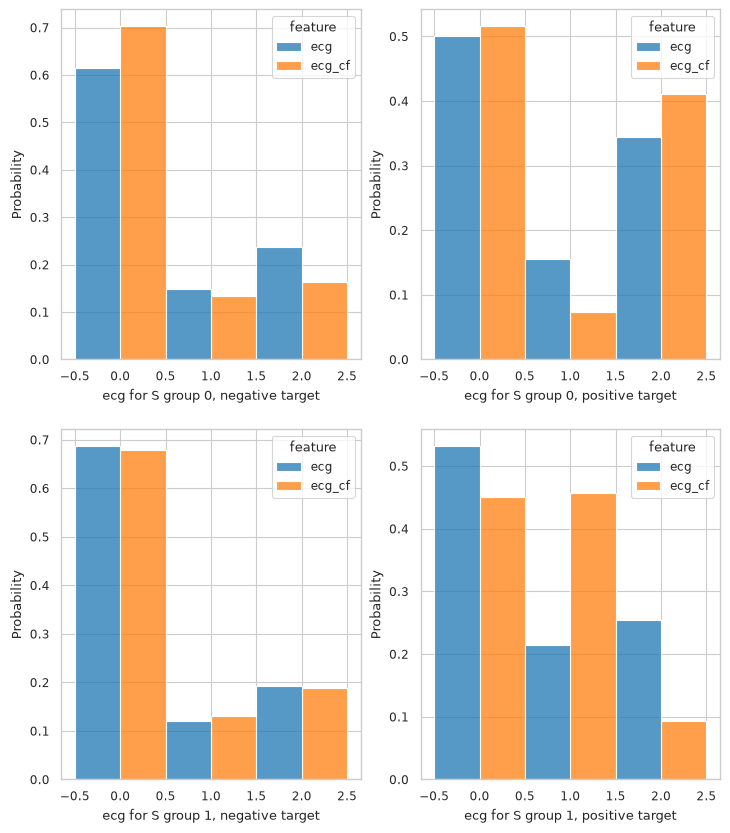

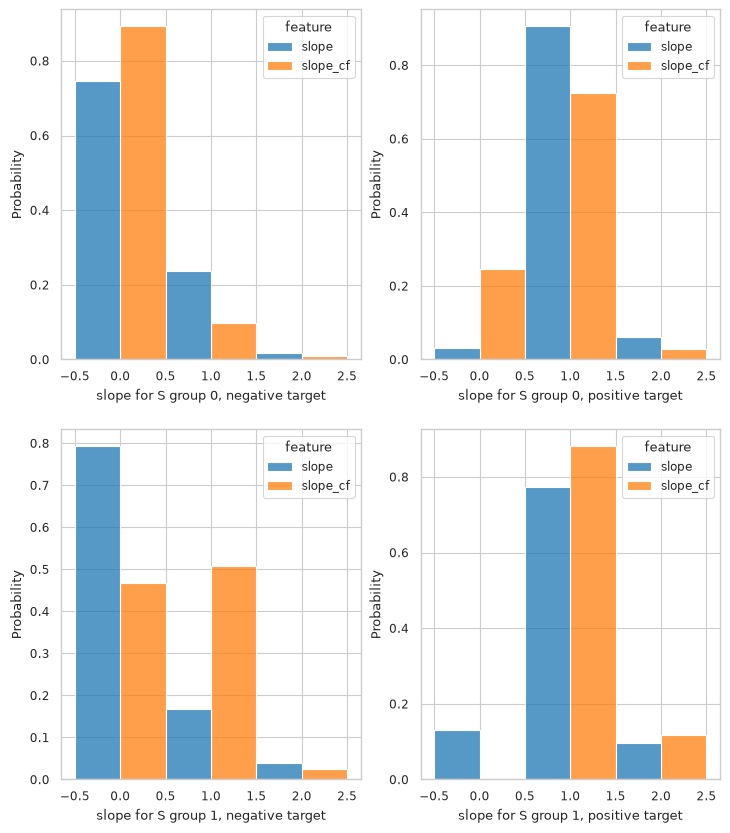

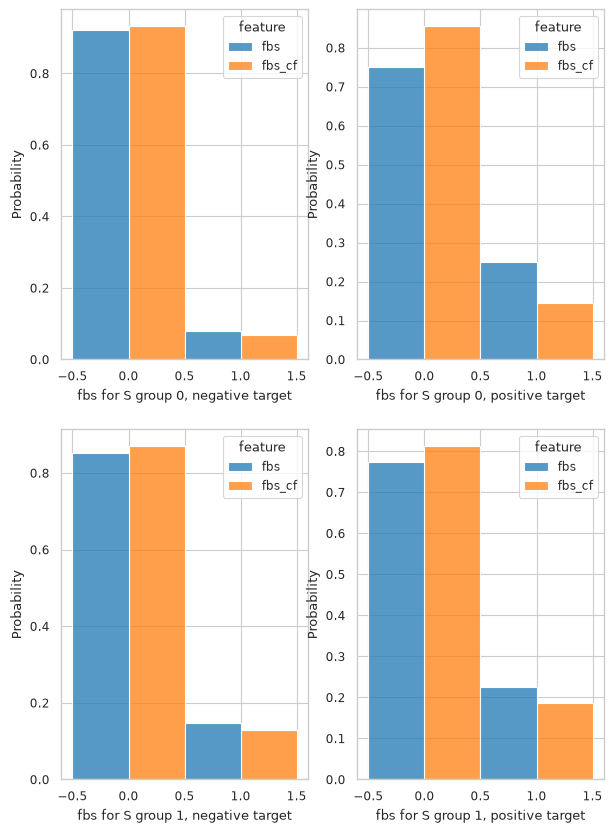

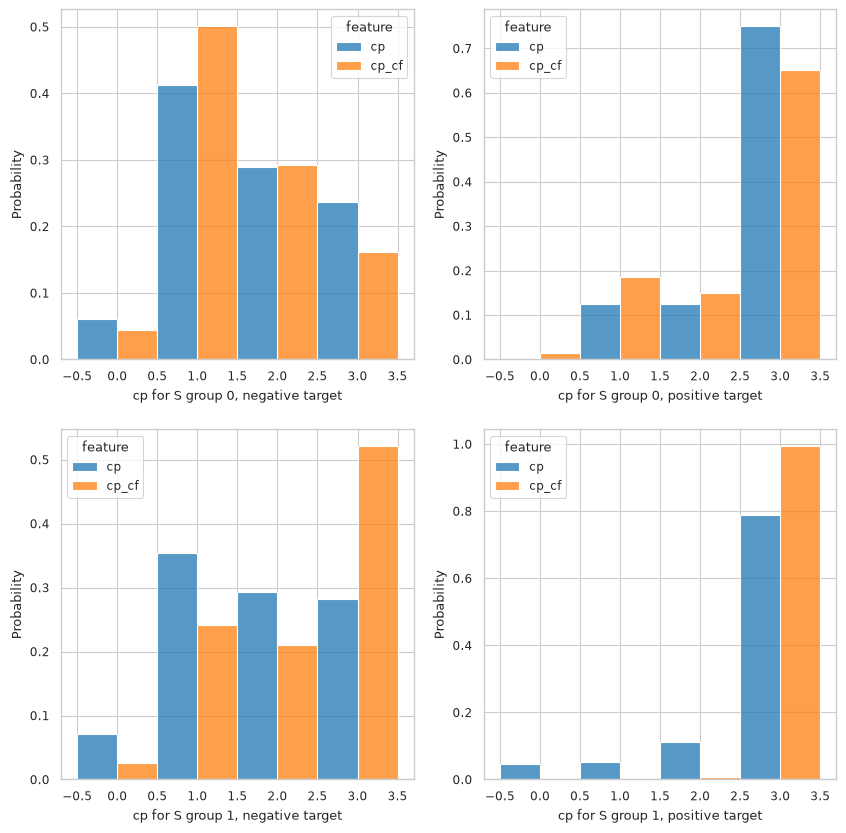

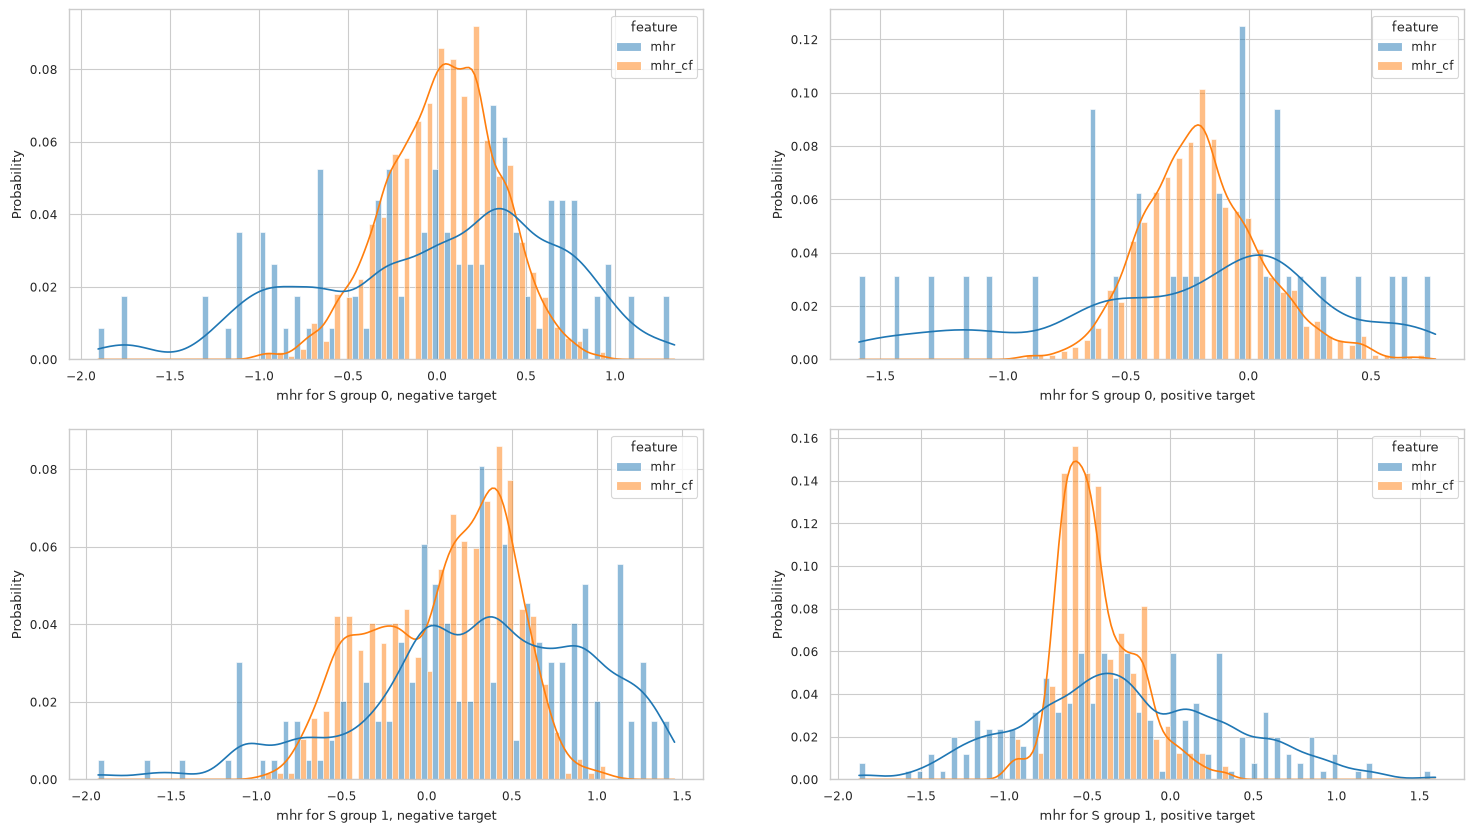

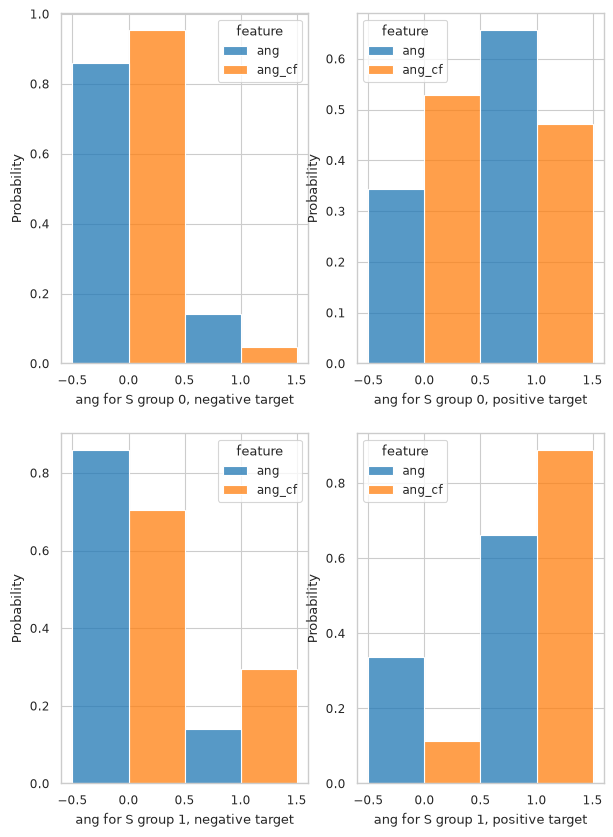

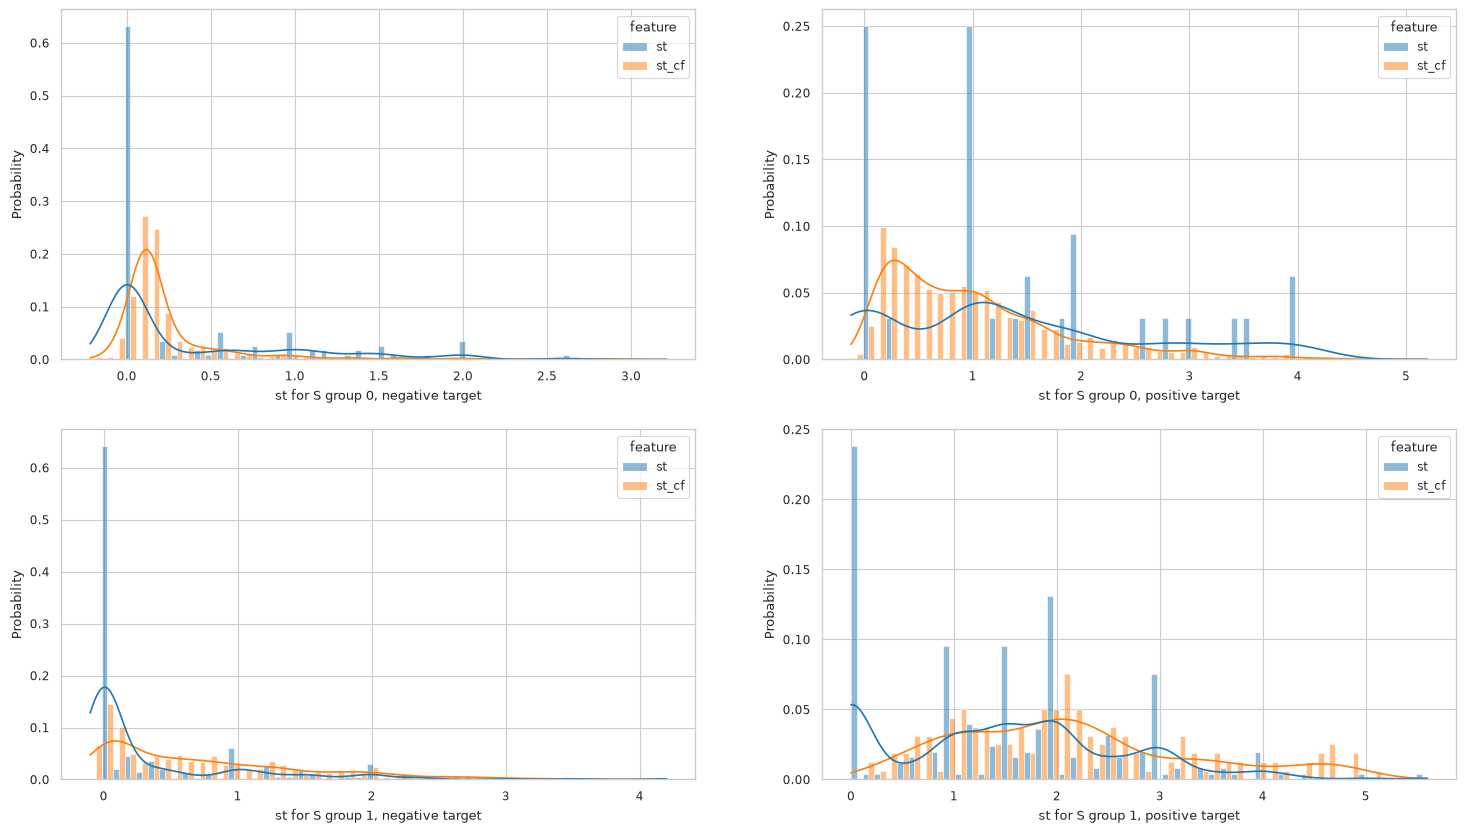

In [40]:
for feature in feature_map['desc']:
  col_name = feature['name']
  cf_col_name = feature['name'] + "_cf"
  group_0_mask = training_df[sens_col] == 0
  group_1_mask = training_df[sens_col] == 1
  if feature['type'] == "continuous":
    plot_cf_cont_feature_comparison(training_df, col_name, cf_col_name, sens_col, target_col)
  else:
    plot_cf_cat_feature_comparison(training_df, col_name, cf_col_name, sens_col, target_col)